In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl as op


In [49]:
df = pd.read_excel("dados_vendas.xlsx")
print(df.head())

        Data  Quantidade Vendida
0 2022-01-01                 102
1 2022-01-02                 102
2 2022-01-03                 107
3 2022-01-04                 102
4 2022-01-05                 104


Text(0.5, 0, 'Data')

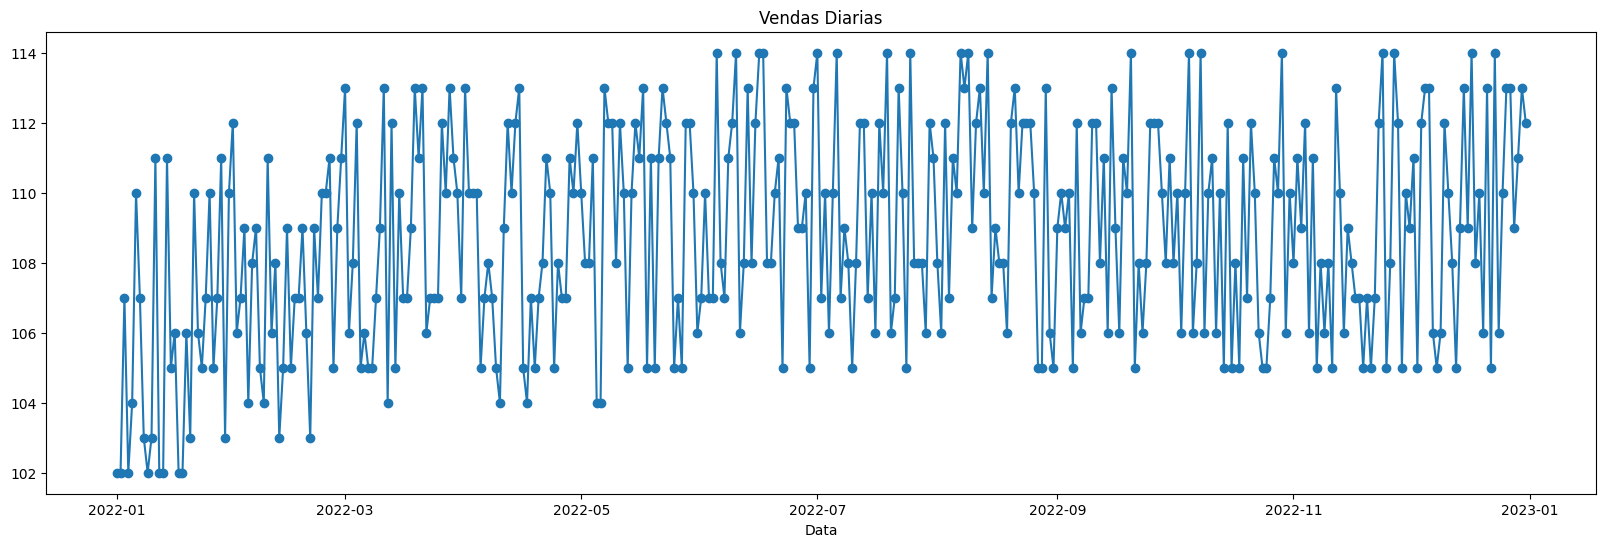

In [50]:
#Grafico de linhas com vendas diarias
plt.figure(figsize=(20,6))
plt.plot(df["Data"], df["Quantidade Vendida"], marker="o")
plt.title("Vendas Diarias")
plt.xlabel("Data")  

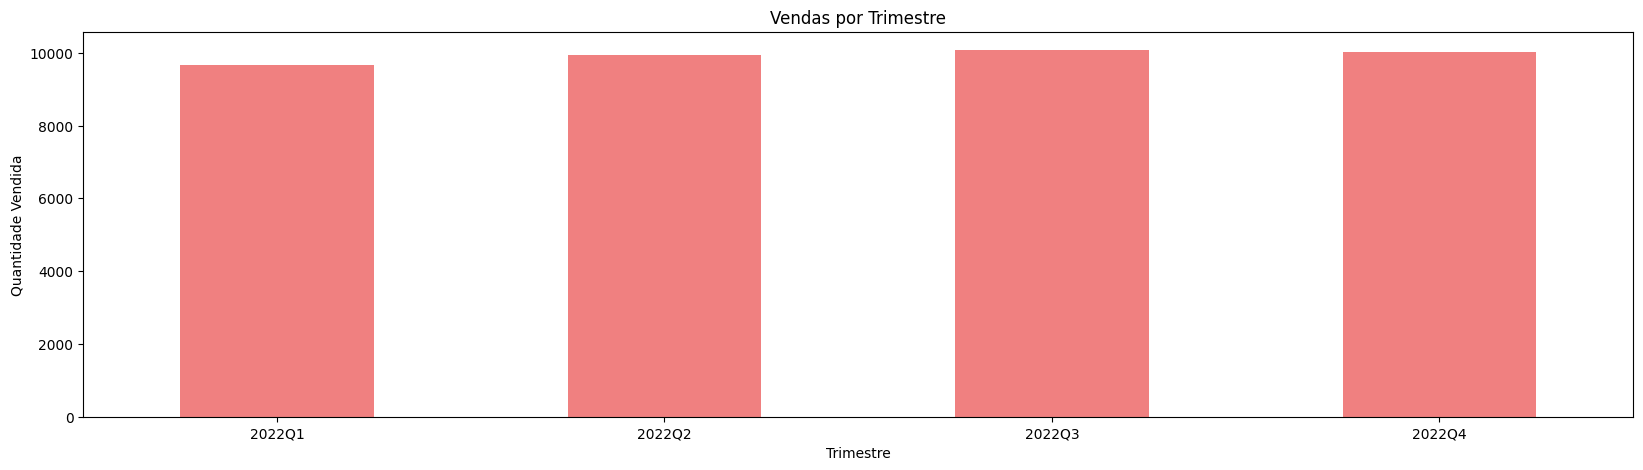

In [67]:
#analise de venda por trimestre
df["Data"] = pd.to_datetime(df["Data"]) 
df["Trimestre"] = df["Data"].dt.to_period("Q")
vendas_por_trimestre = df.groupby("Trimestre")["Quantidade Vendida"].sum()  


#grafico de vendas por trimestre   
plt.figure(figsize=(20,5))
vendas_por_trimestre.plot(kind="bar", color="lightcoral")
plt.title("Vendas por Trimestre")
plt.xlabel("Trimestre")     
plt.ylabel("Quantidade Vendida")
plt.xticks(rotation=0)  
#plt.yticks(range(0, int(vendas_por_trimestre.max()) + 30, 30))
plt.show()

In [52]:
#identificar o dia com maior venda 
max_vendas = df["Quantidade Vendida"].max()
dia_max_vendas = df[df["Quantidade Vendida"] == max_vendas]["Data"].iloc[0] #.iloc[0] para pegar o primeiro valor caso haja mais de um dia com a mesma quantidade maxima
print(f"O dia com maior venda foi: {dia_max_vendas} com {max_vendas} vendas.")  

#identificar o dia com menor venda  
min_vendas = df["Quantidade Vendida"].min() 
dia_min_vendas = df[df["Quantidade Vendida"] == min_vendas]["Data"].iloc[0] #.iloc[0] para pegar o primeiro valor caso haja mais de um dia com a mesma quantidade minima
print(f"O dia com menor venda foi: {dia_min_vendas} com {min_vendas} vendas.")  


O dia com maior venda foi: 2022-06-05 00:00:00 com 114 vendas.
O dia com menor venda foi: 2022-01-01 00:00:00 com 102 vendas.


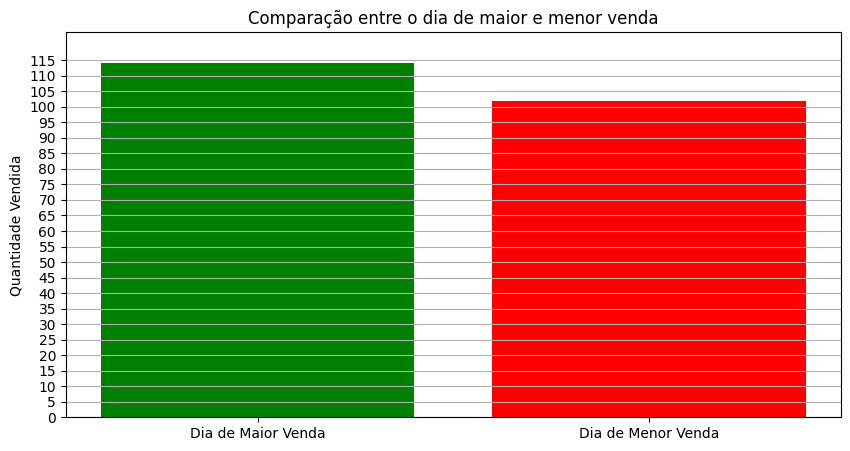

In [53]:
#grafico de barras com os dias de maior e menor venda   
plt.figure(figsize=(10,5))
plt.bar(["Dia de Maior Venda", "Dia de Menor Venda"], [max_vendas, min_vendas], color=["green", "red"])
plt.title("Comparação entre o dia de maior e menor venda")  
plt.ylabel("Quantidade Vendida")
plt.grid(axis='y') # Adiciona uma grade apenas no eixo y

plt.ylim(0, max_vendas + 10)    
plt.yticks(range(0, max_vendas + 5, 5))
plt.show()


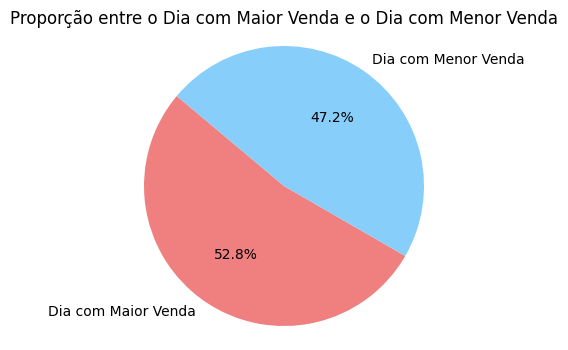

In [54]:
#grafico pie com a data do dia com maior venda e do dia com menor venda
labels = ["Dia com Maior Venda", "Dia com Menor Venda"] 
sizes = [max_vendas, min_vendas]
colors = ["lightcoral", "lightskyblue"]     
plt.figure(figsize=(6,4))
plt.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=140)
plt.title("Proporção entre o Dia com Maior Venda e o Dia com Menor Venda")
plt.axis("equal")       
plt.show()



In [55]:
#calculo medio das vendas diarias ao longo do ano
media_vendas = df["Quantidade Vendida"].mean().round(0)
print(f"A média de vendas diárias ao longo do ano foi: {media_vendas} vendas.")   

A média de vendas diárias ao longo do ano foi: 109.0 vendas.


In [70]:
#Agrupe os dados por mes e calcule a media de vendas para cada mes.
df["Data"] = pd.to_datetime(df["Data"])
df["Mes"] = df["Data"].dt.month
media_vendas_por_mes = df.groupby("Mes")["Quantidade Vendida"].mean().round(0)
print("Média de vendas por mês:")
print(media_vendas_por_mes) 

Média de vendas por mês:
Mes
1     106.0
2     107.0
3     109.0
4     108.0
5     109.0
6     110.0
7     109.0
8     110.0
9     109.0
10    109.0
11    108.0
12    110.0
Name: Quantidade Vendida, dtype: float64


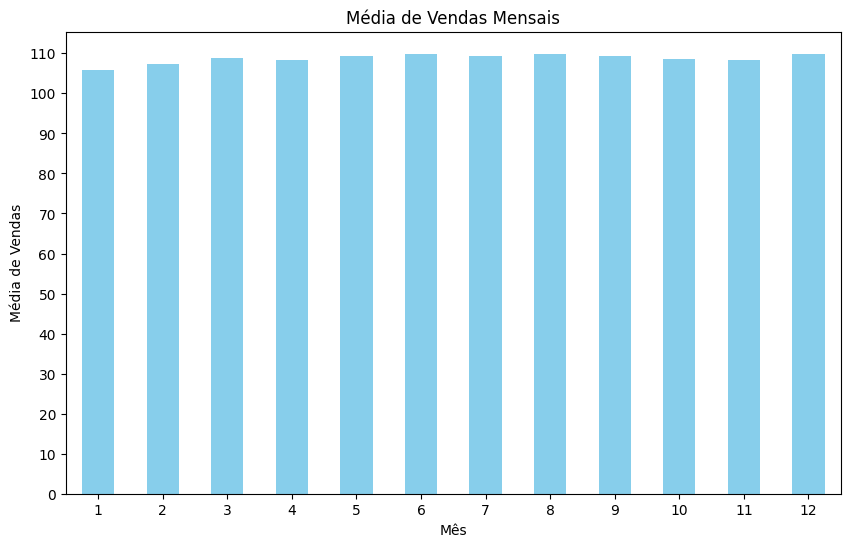

In [57]:
#• Plote um grafico de barras mostrando a media de vendas mensais.
plt.figure(figsize=(10,6))
media_vendas_por_mes.plot(kind="bar", color="skyblue")
plt.title("Média de Vendas Mensais")    
plt.xlabel("Mês")   
plt.ylabel("Média de Vendas")   
plt.xticks(rotation=0)  
plt.yticks(range(0, int(media_vendas_por_mes.max()) + 10, 10))  
plt.show()  